# Reading and plotting EOVSA all-day synoptic spectrogram and images
This notebook demonstrates how to read and plot EOVSA all-day synoptic spectrogram and images using Python.

## Section 1: Understanding Naming Conventions

EOVSA data products follow specific naming conventions that facilitate easy identification and access.

### Data Products & Their Naming Conventions

- **Synoptic Spectrograms**
  - TP Spectrograms: `EOVSA_TPall_yyyymmdd.fts`
  - XP Spectrograms: `EOVSA_XPall_yyyymmdd.fts`

- **Synoptic Images**
  - 1.4 GHz images: `eovsa_yyyymmdd.spw00-01.tb.disk.fits`
  - 3.0 GHz images: `eovsa_yyyymmdd.spw02-05.tb.disk.fits`
  - 4.5 GHz images: `eovsa_yyyymmdd.spw06-10.tb.disk.fits`
  - 6.8 GHz images: `eovsa_yyyymmdd.spw11-20.tb.disk.fits`
  - 10.2 GHz images: `eovsa_yyyymmdd.spw21-30.tb.disk.fits`
  - 13.9 GHz images: `eovsa_yyyymmdd.spw31-43.tb.disk.fits`

**Required Python Packages:** Astropy, Sunpy, and Radiospectra are essential for processing the FITS files.

**Data Access:** Explore and download EOVSA data through the [EOVSA Data Browser](https://ovsa.njit.edu/browser) or directly via the
base URL formatted by date: https://ovsa.njit.edu/fits/synoptic/YYYY/MM/DD/.


## Section 2: Download and Read daily synoptic spectrograms and images

###  Download and read daily synoptic spectrograms

One can directly use the url to download the spectrogram files, e.g., https://ovsa.njit.edu/fits/synoptic/2021/05/07/EOVSA_TPall_20210507.fts

Alternatively, one can download them using SunPy and Radiospectra:

In [ ]:
# Ensure all required packages are installed
!pip install astropy sunpy[net] radiospectra

In [113]:
# Example to read EOVSA All-day spectrogram FITS file
# Let's use the total power (TP) spectrogram as an example
import radiospectra.net
from sunpy.net import Fido, attrs as a
from radiospectra.spectrogram import Spectrogram
from datetime import datetime, timedelta

# Define your date and product type
date = datetime(2021, 5, 7)

# Product type selection:
# For total power spectrograms, use radiospectra.net.PolType.total
# For cross power spectrograms, use radiospectra.net.PolType.cross
product_type = radiospectra.net.PolType.total

# Construct the query and download
# query the data in the time range of 2021-05-07 00:00:00 to 2021-05-07 23:00:00
query = Fido.search(a.Time(date, date + timedelta(hours=23)), a.Instrument('eovsa'), radiospectra.net.PolType.total)
downloaded_files = Fido.fetch(query)
eovsa_file = downloaded_files[0]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

EOVSA_TPall_20210507.fts:   0%|          | 0.00/65.6M [00:00<?, ?B/s]

In [114]:
# Use astropy.io.fits to read the spectrogram data
from astropy.io import fits
from astropy.time import Time

hdu = fits.open(eovsa_file)
eospecdata = hdu[0].data  # spectrogram data in (n_frequency, n_time)
fghz = hdu[1].data['sfreq']  # frequency axis (n_frequency), in GHz
eotime = Time(hdu[2].data['mjd'], format='mjd')  # time axis (n_time), in mjd

In [115]:
# Alternatively, loading the spectrogram is easy with radiospectra.spectrogram
eospec = Spectrogram(eovsa_file)
print(f'Spectrogram shape: {eospec.data.shape}')
eospecdata = eospec.data
fghz = eospec.frequencies.value
eotime = eospec.times

TypeError: Spectrogram.__init__() missing 4 required positional arguments: 'time_axis', 'freq_axis', 'start', and 'end'

### Download and read daily synotpic images

As an example, we use the observations made on November 23, 2021, at frequencies of 3.0 GHz, 6.8 GHz, and 13.9 GHz. These frequencies correspond to the spectral window ranges '02-05', '11-20', and '31-43', as defined in Section 1. The FITS files for these images are available at the base URL formatted by date: https://ovsa.njit.edu/fits/synoptic/YYYY/MM/DD/. Here we use sunpy to download and read the EOVSA images as sunpy maps.

In [28]:
import sunpy.map
from datetime import datetime

# Define the date for the data you're interested in
date = datetime(2021, 11, 23)
date_str = date.strftime('%Y%m%d')
base_url = f'https://ovsa.njit.edu/fits/synoptic/{date.strftime("%Y/%m/%d")}/'

# List of spectral windows and corresponding file names
spws = ['02-05', '11-20', '31-43']
file_names = [f'eovsa_{date_str}.spw{spw}.tb.disk.fits' for spw in spws]
urls = [base_url + name for name in file_names]

# Load the FITS files as SunPy Map objects
eomaps = [sunpy.map.Map(url) for url in urls]


## Section 3: Plotting daily synoptic spectrograms and images
Now you are all set and can use your favorate method to plot the data! This section provides concise examples of visualizing EOVSA synoptic spectrograms and images with matplotlib (https://matplotlib.org/), radiospectra (https://docs.sunpy.org/projects/radiospectra/en/latest/), and Sunpy (https://sunpy.org/). Experienced users can skip the following and jsut start to do science!



### Enabling Interactive Backend for Matplotlib in Jupyter Notebooks

If you need an interactive backend for Matplotlib within Jupyter Notebooks, this block allows you to zoom, pan, and interact directly with the plot in the notebook cell. This can be especially useful for exploring complex data visualizations, such as spectrograms. If you only need to see a static version of the plot, you can skip this block and proceed with the standard `%matplotlib inline` for static plots.

The following code installs and enables the interactive plotting tools in Google Colab or Jupyter Notebooks:


In [5]:
# Install ipympl, which provides an interactive Matplotlib backend for Jupyter Notebooks
!pip install ipympl

try:
    # Enable the custom widget manager in Google Colab for interactive widgets
    from google.colab import output

    output.enable_custom_widget_manager()
except:
    pass

# Use the widget backend for interactive plots
%matplotlib widget

### Plotting the Spectrogram

Spectrogram Dimensions - Frequencies: 451, Time Points: 36180


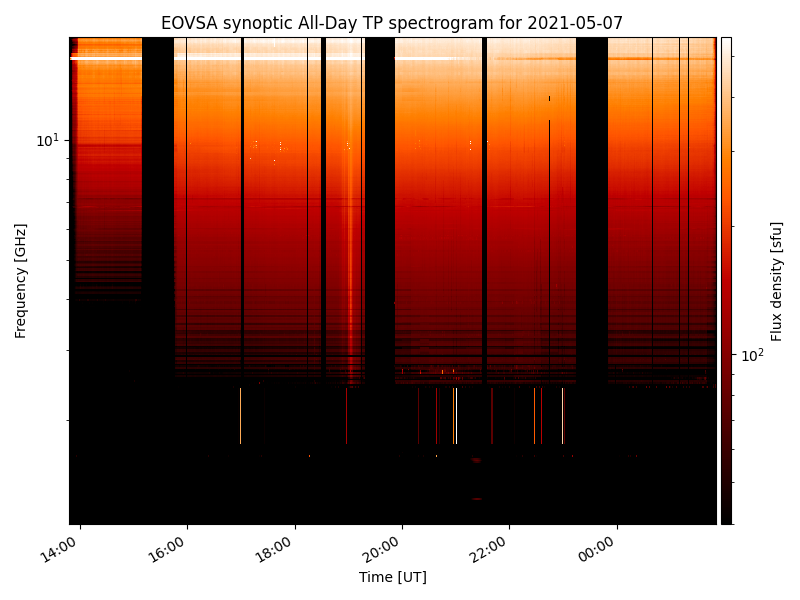

In [ ]:
import os
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
import numpy as np

# Access the spectrogram data: frequencies (GHz), times, and the data in solar flux units (sfu)
timplt = eotime.plot_date
ntim = len(eotime)
nfreq = len(fghz)
print(f'Spectrogram Dimensions - Frequencies: {nfreq}, Time Points: {ntim}')

# Initialize figure and axis for plotting the spectrogram
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot()

# Plot the spectrogram using a logarithmic color scale
norm = LogNorm(vmax=np.percentile(eospec.data, 99), vmin=40)
cmap = plt.get_cmap('gist_heat')
pcm = eospec.plot(axes=ax, cmap=cmap, norm=norm)
ax.xaxis_date()  # Use date format for the x-axis
ax.xaxis.set_major_formatter(DateFormatter("%H:%M"))  # Format time display
ax.set_ylim(fghz[0], fghz[-1])  # Set frequency range
ax.set_yscale('log')  # Use log scale
ax.set_xlim(eotime[0].plot_date, eotime[-1].plot_date)  # Set time range
ax.set_xlabel('Time [UT]')  # Label for the x-axis
ax.set_ylabel('Frequency [GHz]')  # Label for the y-axis
ax.set_title('EOVSA synoptic All-Day TP spectrogram for ' + eotime[0].datetime.strftime('%Y-%m-%d'))

# Add a colorbar to the right of the spectrogram
divider = make_axes_locatable(ax)
cax_spec = divider.append_axes('right', size='1.5%', pad=0.05)
clb_spec = plt.colorbar(pcm, ax=ax, cax=cax_spec, label='Flux density [sfu]')

# Time gaps masking for time intervals when solar data is missing due to calibration scans.
bkg_facecolor = cmap(0.0)
ax.set_facecolor(bkg_facecolor)
dtim = np.diff(eotime.mjd)
idxs_tgap = np.where(dtim * 24 * 60 >= 0.5)[0]
if len(idxs_tgap) > 0:
    for idx in idxs_tgap:
        if idx + 1 < ntim:
            ax.axvspan(eotime[idx].plot_date, eotime[idx + 1].plot_date, facecolor=bkg_facecolor, edgecolor='none')


def format_coord(x, y):
    """Function to display time, frequency, and flux density at cursor position."""
    col = np.argmin(np.absolute(timplt - x))
    row = np.argmin(np.absolute(fghz - y))
    if col >= 0 and col < ntim and row >= 0 and row < nfreq:
        timstr = eotime[col].isot
        flux = eospecdata[row, col]
        return 'Time: {0}, Frequency: {1:.3f} GHz, Flux density: {2:.2f} sfu'.format(timstr, y, flux)
    else:
        return 'x = {0}, y = {1:.3f}'.format(x, y)


ax.format_coord = format_coord
fig.tight_layout()
plt.show()

### Plotting the synoptic images
In the following, we will plot EOVSA all-day synoptic images for specific frequency bands corresponding to 3.0 GHz, 6.8 GHz, and 13.9 GHz, represented in units of brightness temperature (K).

In [2]:
# Example of using sunpy.map to plot the EOVSA All-day synoptic images at
# band ['02-05', '11-20', '31-43'] with corresponding to 3.0 GHz, 6.8 GHz, and 13.9 GHz
# The images are in units of brightness temperature [K]

import sunpy.map
import matplotlib.pyplot as plt

# Configure color map to be used for the plot
cmap = plt.get_cmap('sdoaia304')

# Initialize figure with a specific size
fig = plt.figure(figsize=(15, 4))

# Iterate over each EOVSA map object to plot
for n, eomap in enumerate(eomaps):
    ax = fig.add_subplot(1, len(eomaps), n + 1, projection=eomap)
    eomap.plot(axes=ax, cmap=cmap)
    eomap.draw_limb()  # Highlight the solar limb for context
    freq = eomap.meta['restfrq'] / 1e9  # reference frequency of the map in GHz
    ax.set_title('EOVSA ' + eomap.date.datetime.strftime('%Y-%m-%d') + f' {freq:.1f} GHz')
    cbar = plt.colorbar()
    cbar.set_label('Brightness Temp. [K]', labelpad=15)
fig.tight_layout()

### Adjusting Image Brightness

Directly using the max and min values from the FITS files may not adequately highlight the solar disk due to the intense brightness of active regions. To address this, we adjust the colormap scaling using the `AsinhStretch` method from Astropy for a balanced visualization.

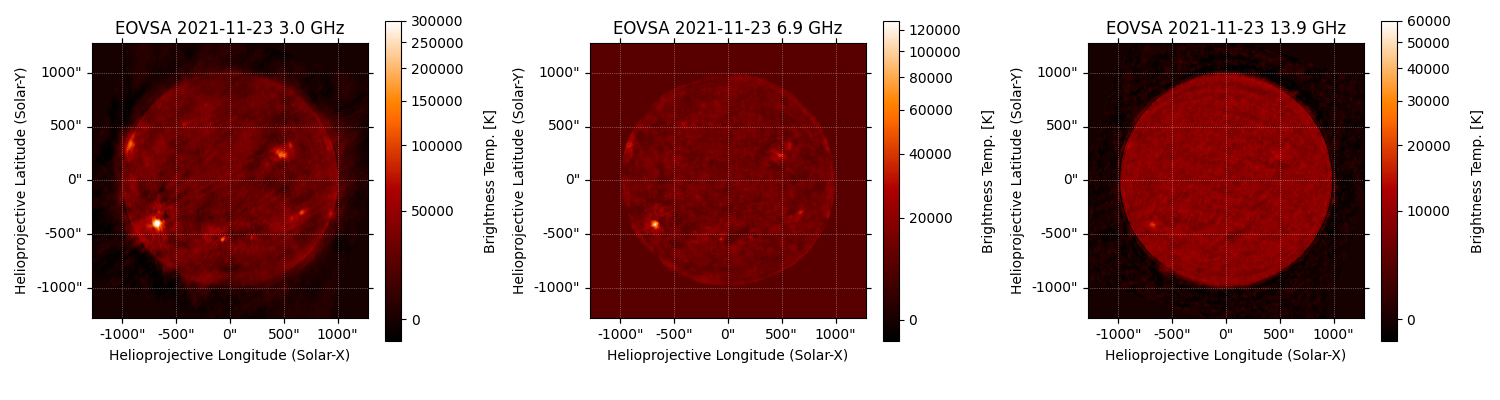

In [24]:
from astropy.visualization import ImageNormalize, AsinhStretch
import re

# Define SPWs and their corresponding vmax and vmin values for scaling
spws = ['00-01', '02-05', '06-10', '11-20', '21-30', '31-43', '44-49']
vmaxs = [7e5, 3e5, 1.8e5, 1.3e5, 8e4, 6e4, 6e4]  # Maximum brightness temp. values
vmins = [-1.8e4, -8e3, -4.8e3, -3.4e3, -2.1e3, -1.6e3, -1.6e3]  # Minimum brightness temp. values

# Associate SPWs with their vmax and vmin values
v_dict = {spw: {'vmax': vmax, 'vmin': vmin} for spw, vmax, vmin in zip(spws, vmaxs, vmins)}

# Apply adaptive stretching for better visual contrast
stretch = AsinhStretch(a=0.15)
# Extract SPW strings from file names for matching vmax and vmin values
spwstr_list = [re.search(r'spw\d{2}-\d{2}', name).group().replace('spw', '') for name in file_names]
fig = plt.figure(figsize=(15., 4))
for n, (eomap, spwstr) in enumerate(zip(eomaps, spwstr_list)):
    ax = fig.add_subplot(1, len(eomaps), n + 1, projection=eomap)
    vmax = v_dict[spwstr]['vmax']
    vmin = v_dict[spwstr]['vmin']
    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    eomap.plot(axes=ax, cmap=cmap, norm=norm)
    freq = eomap.meta['restfrq'] / 1e9  # reference frequency of the map in GHz
    ax.set_title('EOVSA ' + eomap.date.datetime.strftime('%Y-%m-%d') + f' {freq:.1f} GHz')
    cbar = plt.colorbar()
    cbar.set_label('Brightness Temp. [K]', labelpad=15)
fig.tight_layout()

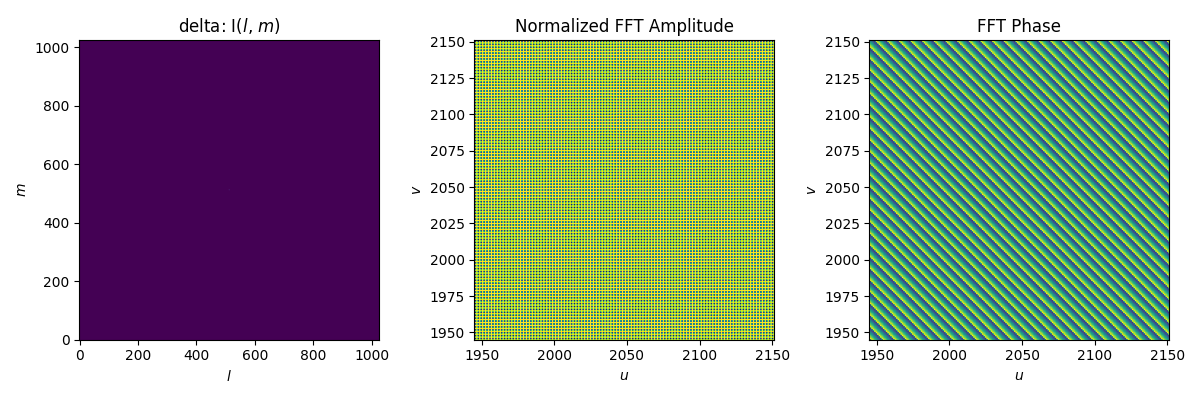

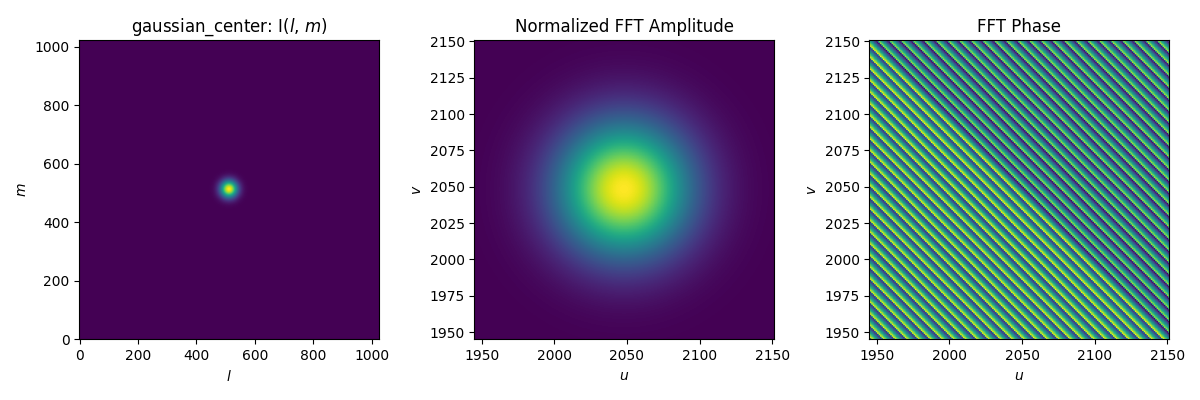

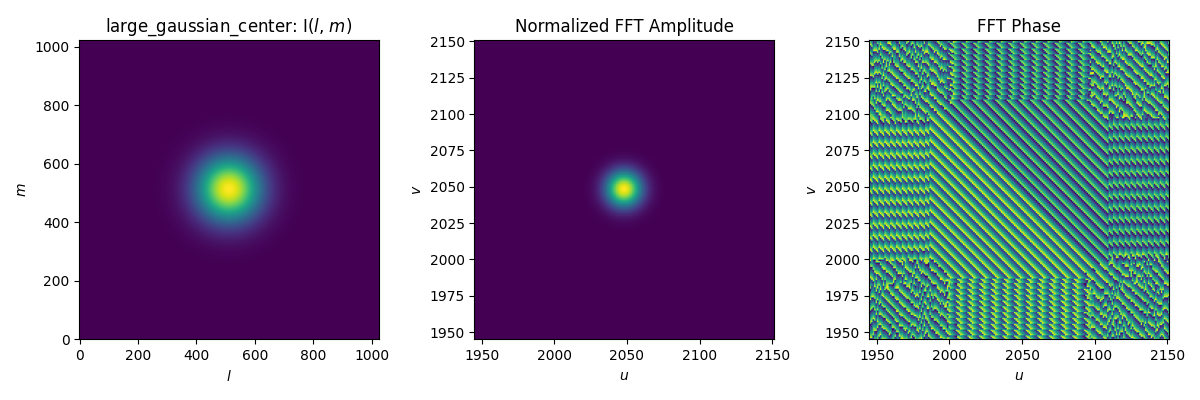

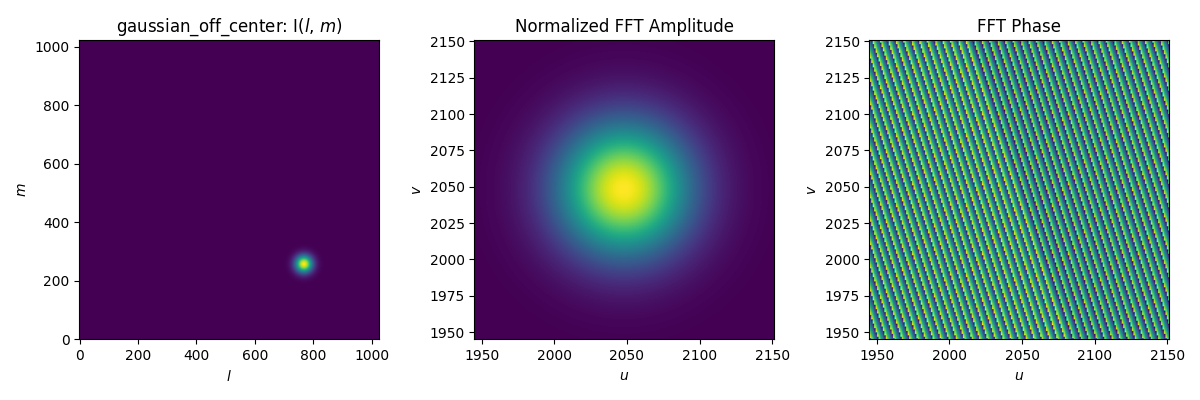

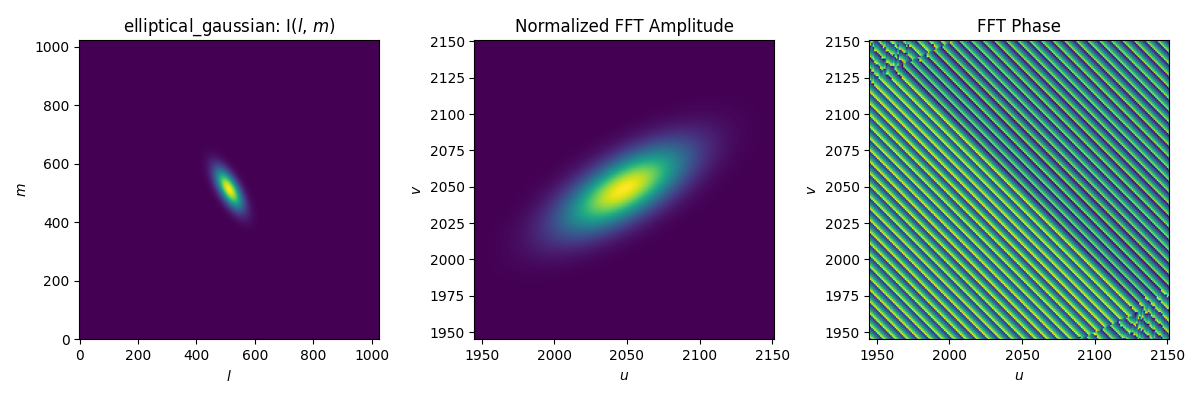

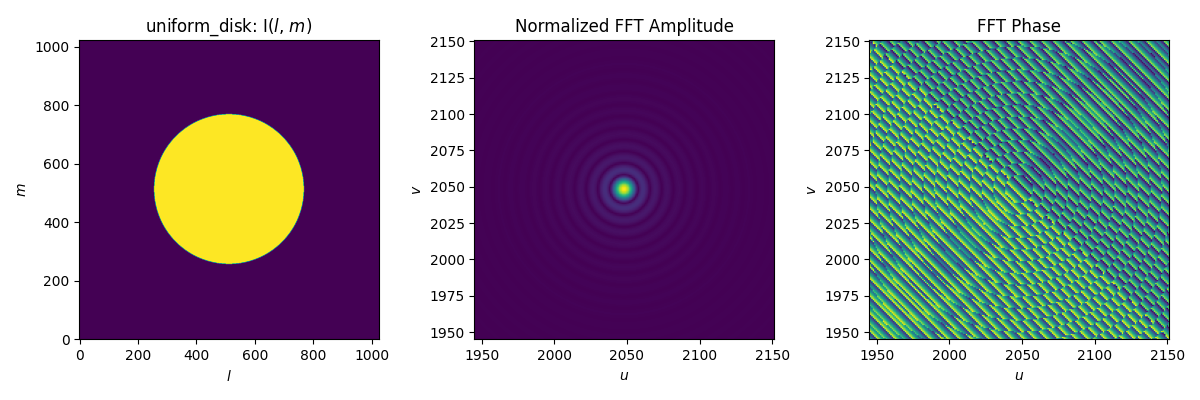

In [105]:
plt.close('all')